<a href="https://colab.research.google.com/github/ganeshkumar1887/Natural-language-processing-/blob/main/Basic%20NLP%20tasks/Sentiment_analysis_and_preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nltk matplotlib wordcloud

In [ ]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

Tokenization

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.



Original Text: 
 
Natural Language processing is very interasting and powerful.
Students love  learning NLP because it helps in building intelligent systems.
However, sometimes coding can be defficult and confusing.


tokens :
 ['natural', 'language', 'processing', 'is', 'very', 'interasting', 'and', 'powerful', '.', 'students', 'love', 'learning', 'nlp', 'because', 'it', 'helps', 'in', 'building', 'intelligent', 'systems', '.', 'however', ',', 'sometimes', 'coding', 'can', 'be', 'defficult', 'and', 'confusing', '.']

 After removing punctuation : ['natural', 'language', 'processing', 'is', 'very', 'interasting', 'and', 'powerful', 'students', 'love', 'learning', 'nlp', 'because', 'it', 'helps', 'in', 'building', 'intelligent', 'systems', 'however', 'sometimes', 'coding', 'can', 'be', 'defficult', 'and', 'confusing']

 Afetr remove Stopwords
 :  ['natural', 'language', 'processing', 'interasting', 'powerful', 'students', 'love', 'learning', 'nlp', 'helps', 'building', 'intelligent', '

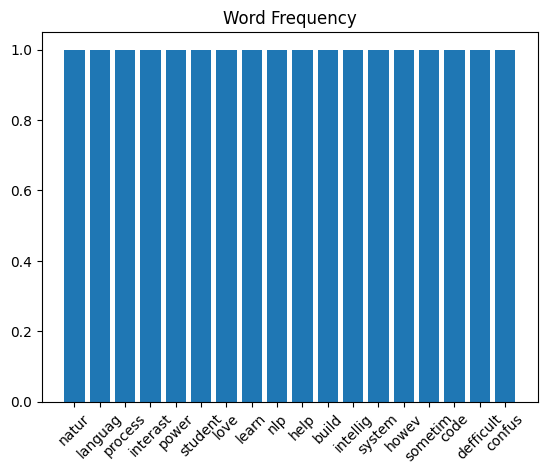

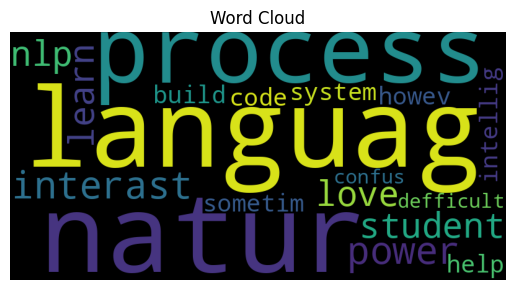


 Sentiment Score ;
 {'neg': 0.05, 'neu': 0.549, 'pos': 0.402, 'compound': 0.9255}

 Overrall Sentiment: Positive 😂


In [ ]:
import nltk
import string
import matplotlib.pyplot as plt
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer
from nltk.sentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud
from collections import Counter


# Download Require datasets

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('vader_lexicon')
nltk.download('punkt_tab')


# Input Text

text="""
Natural Language processing is very interasting and powerful.
Students love  learning NLP because it helps in building intelligent systems.
However, sometimes coding can be defficult and confusing.
"""

print("\nOriginal Text: \n",text)

#------------------------------
# Step 2 : Tokenization
token=word_tokenize(text.lower())
print("\ntokens :\n",token)

#------------------------------

# REmove Punctuation
tokens=[word for word in token if word.isalpha()]
print("\n After removing punctuation :",tokens)

#----------------------------
# Step4 : Remove Stopword
stop_words= set(stopwords.words('english'))
filteres_word=[word for word in tokens if word not in stop_words]
print("\n Afetr remove Stopwords\n : ",filteres_word)

#---------------------------
# Sep5: Stemming

stemmer=PorterStemmer()
stemmed_word=[stemmer.stem(word) for word in filteres_word]
print("\n After Stemming :\n",stemmed_word)

#----------------------------
# step6 : Word frequency analysis
word_freq= Counter(stemmed_word)
print("\n word frequency :\n",word_freq)

#-----------------------------
# Step7: Plotinng
plt.figure()
plt.bar(word_freq.keys(),word_freq.values())
plt.title("Word Frequency")
plt.xticks(rotation=45)
plt.show()

#-----------------------------------
# Step 8; Wordcloud Visualization
wordcloud=WordCloud(width=800,height=400).generate(" ".join(stemmed_word))
plt.figure()
plt.imshow(wordcloud)
plt.axis('off')
plt.title("Word Cloud")
plt.show()

#----------------------------------
# Step 9 : Sentiment Analysis
sia=SentimentIntensityAnalyzer()
sentiment_score=sia.polarity_scores(text)

print("\n Sentiment Score ;\n",sentiment_score)

if sentiment_score['compound'] >=0.05:
    print("\n Overrall Sentiment: Positive 😂")
elif sentiment_score['compound'] <=-0.05:
    print("\n Overrall Sentiment: Negative 😒")
else:
    print("\n Overrall Sentiment : Neutral  👌")